In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3

Tables from Teen_Mental_Health_Dataset (D1)-

Users- user_id, age, gender
This table represents the students in the study. Each row is one student. The primary key is user_id, prefixed with D1_.

Behavior- user_id, platform_usage, social_interaction_level, stress_level, anxiety_level, addiction_level, depression_label
This table represents the reported psychological and platform behavior fields per student.

Hours- user_id, daily_social_media_hours, sleep_hours, screen_time_before_sleep, academic_performance, physical_activity
This table represents the time-based and outcome fields per student.

Tables from teen_phone_addiction_dataset (D2)-

Users- user_id, age, gender, school_grade
This table represents the students in the study. Each row is one student. The primary key is user_id, prefixed with D2_.

Behavior- user_id, phone_usage_purpose, parental_control, phone_checks_per_day, apps_used_daily, social_interactions, family_communication, self_esteem, anxiety_level, depression_level, addiction_level
This table represents phone habits and self-reported wellbeing fields per student.

Hours- user_id, daily_usage_hours, sleep_hours, screen_time_before_bed, academic_performance, exercise_hours, time_on_social_media, time_on_gaming, time_on_education, weekend_usage_hours
This table represents the time-based and outcome fields per student.

Reminder from the cleanup notebooks before writing any query: academic_performance is not on the same scale in both datasets, D1 is a 2.00 to 4.00 GPA-style score and D2 is a 0 to 100 score. depression_label in D1 is a 0/1 flag, depression_level in D2 is a 1 to 10 scale. Every query below stays inside one dataset at a time for that reason, same approach as the Smartphone project.

In [ ]:
df1 = pd.read_csv('../Data/cleaned_Teen_Mental_Health_Dataset.csv')
df2 = pd.read_csv('../Data/cleaned_teen_phone_addiction_dataset.csv')

Import both cleaned datasets from the CSV files created in the two cleanup notebooks.

In [3]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS users_d1 (
            user_id TEXT PRIMARY KEY,
            age     INTEGER,
            gender  TEXT NOT NULL
        );
    """)

    connection.commit()

Open a connection to Student_MentalHealth.db and create users_d1.

In [4]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS behavior_d1 (
            user_id                    TEXT NOT NULL,
            platform_usage             TEXT,
            social_interaction_level   TEXT,
            stress_level               INTEGER,
            anxiety_level              INTEGER,
            addiction_level            INTEGER,
            depression_label           INTEGER
        );
    """)

    connection.commit()

Create behavior_d1.

In [5]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS hours_d1 (
            user_id                     TEXT NOT NULL,
            daily_social_media_hours    REAL,
            sleep_hours                 REAL,
            screen_time_before_sleep    REAL,
            academic_performance        REAL,
            physical_activity           REAL
        );
    """)

    connection.commit()

Create hours_d1.

In [6]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS users_d2 (
            user_id       TEXT PRIMARY KEY,
            age           INTEGER,
            gender        TEXT NOT NULL,
            school_grade  TEXT
        );
    """)

    connection.commit()

Create users_d2.

In [7]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS behavior_d2 (
            user_id                TEXT NOT NULL,
            phone_usage_purpose    TEXT,
            parental_control       INTEGER,
            phone_checks_per_day   INTEGER,
            apps_used_daily        INTEGER,
            social_interactions    INTEGER,
            family_communication   INTEGER,
            self_esteem            INTEGER,
            anxiety_level          INTEGER,
            depression_level       INTEGER,
            addiction_level        REAL
        );
    """)

    connection.commit()

Create behavior_d2.

In [8]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS hours_d2 (
            user_id                   TEXT NOT NULL,
            daily_usage_hours         REAL,
            sleep_hours               REAL,
            screen_time_before_bed    REAL,
            academic_performance      REAL,
            exercise_hours            REAL,
            time_on_social_media      REAL,
            time_on_gaming            REAL,
            time_on_education         REAL,
            weekend_usage_hours       REAL
        );
    """)

    connection.commit()

Create hours_d2.

In [9]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    print(cursor.fetchall())

[('users_d1',), ('behavior_d1',), ('hours_d1',), ('users_d2',), ('behavior_d2',), ('hours_d2',)]


All six tables exist. Using if_exists='replace' on every to_sql call below so rerunning this notebook never doubles up rows.

In [10]:
users_d1 = df1[['user_id', 'age', 'gender']]

with sqlite3.connect('Student_MentalHealth.db') as connection:
    users_d1.to_sql('users_d1', connection, if_exists='replace', index=False)

In [11]:
behavior_d1 = df1[[
    'user_id', 'platform_usage', 'social_interaction_level',
    'stress_level', 'anxiety_level', 'addiction_level', 'depression_label'
]]

with sqlite3.connect('Student_MentalHealth.db') as connection:
    behavior_d1.to_sql('behavior_d1', connection, if_exists='replace', index=False)

In [12]:
hours_d1 = df1[[
    'user_id', 'daily_social_media_hours', 'sleep_hours',
    'screen_time_before_sleep', 'academic_performance', 'physical_activity'
]]

with sqlite3.connect('Student_MentalHealth.db') as connection:
    hours_d1.to_sql('hours_d1', connection, if_exists='replace', index=False)

In [13]:
users_d2 = df2[['user_id', 'age', 'gender', 'school_grade']]

with sqlite3.connect('Student_MentalHealth.db') as connection:
    users_d2.to_sql('users_d2', connection, if_exists='replace', index=False)

In [14]:
behavior_d2 = df2[[
    'user_id', 'phone_usage_purpose', 'parental_control', 'phone_checks_per_day',
    'apps_used_daily', 'social_interactions', 'family_communication',
    'self_esteem', 'anxiety_level', 'depression_level', 'addiction_level'
]]

with sqlite3.connect('Student_MentalHealth.db') as connection:
    behavior_d2.to_sql('behavior_d2', connection, if_exists='replace', index=False)

In [15]:
hours_d2 = df2[[
    'user_id', 'daily_usage_hours', 'sleep_hours', 'screen_time_before_bed',
    'academic_performance', 'exercise_hours', 'time_on_social_media',
    'time_on_gaming', 'time_on_education', 'weekend_usage_hours'
]]

with sqlite3.connect('Student_MentalHealth.db') as connection:
    hours_d2.to_sql('hours_d2', connection, if_exists='replace', index=False)

Loaded all six dataframes into their matching tables.

In [16]:
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    for table in ['users_d1', 'behavior_d1', 'hours_d1', 'users_d2', 'behavior_d2', 'hours_d2']:
        cursor.execute(f'SELECT COUNT(*) FROM {table}')
        print(table, cursor.fetchone())

users_d1 (1200,)
behavior_d1 (1200,)
hours_d1 (1200,)
users_d2 (3000,)
behavior_d2 (3000,)
hours_d2 (3000,)


users_d1, behavior_d1, and hours_d1 each hold 1200 rows, matching the cleaned D1 CSV. users_d2, behavior_d2, and hours_d2 each hold 3000 rows, matching the cleaned D2 CSV. Row counts confirm nothing was lost or duplicated on load.

Basic SQL queries first.

In [17]:
#Display first 5 students in D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("SELECT * FROM users_d1 LIMIT 5;")
    for row in cursor.fetchall():
        print(row)

('D1_0001', 14, 'male')
('D1_0002', 19, 'female')
('D1_0003', 17, 'female')
('D1_0004', 15, 'male')
('D1_0005', 15, 'female')


In [18]:
#Min, max, and average age in D1 and D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("SELECT MIN(age), MAX(age), AVG(age) FROM users_d1;")
    print('D1:', cursor.fetchone())
    cursor.execute("SELECT MIN(age), MAX(age), AVG(age) FROM users_d2;")
    print('D2:', cursor.fetchone())

D1: (13, 19, 15.928333333333333)
D2: (13, 19, 15.969666666666667)


Both datasets run 13 to 19 with an average close to 16 in each, confirming they cover the same age band and can be compared side by side.

In [19]:
#Gender counts in D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("SELECT gender, COUNT(*) FROM users_d1 GROUP BY gender;")
    for row in cursor.fetchall():
        print(row)

('female', 585)
('male', 615)


In [20]:
#Gender counts in D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("SELECT gender, COUNT(*) FROM users_d2 GROUP BY gender;")
    for row in cursor.fetchall():
        print(row)

('Female', 1007)
('Male', 1016)
('Other', 977)


D1 only has male and female. D2 has a third Other category at close to a third of the rows. Keep that in mind when comparing gender splits across the two datasets.

Joins next, connecting users to their hours and behavior within each dataset.

In [21]:
#Average sleep hours by gender, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT u.gender, ROUND(AVG(h.sleep_hours), 2) AS avg_sleep
        FROM users_d1 u
        JOIN hours_d1 h ON u.user_id = h.user_id
        GROUP BY u.gender;
    """)
    for row in cursor.fetchall():
        print(row)

('female', 6.5)
('male', 6.4)


In [22]:
#Average sleep hours by gender, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT u.gender, ROUND(AVG(h.sleep_hours), 2) AS avg_sleep
        FROM users_d2 u
        JOIN hours_d2 h ON u.user_id = h.user_id
        GROUP BY u.gender;
    """)
    for row in cursor.fetchall():
        print(row)

('Female', 6.5)
('Male', 6.5)
('Other', 6.47)


Sleep averages sit close together across gender in both datasets, within a few tenths of an hour. No gender stands out as sleeping notably less.

In [23]:
#Average addiction level by age, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT u.age, ROUND(AVG(b.addiction_level), 2) AS avg_addiction
        FROM users_d1 u
        JOIN behavior_d1 b ON u.user_id = b.user_id
        GROUP BY u.age
        ORDER BY avg_addiction DESC;
    """)
    for row in cursor.fetchall():
        print(row)

(19, 5.91)
(17, 5.78)
(13, 5.75)
(18, 5.58)
(16, 5.41)
(15, 5.28)
(14, 5.2)


In [24]:
#Average addiction level by age, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT u.age, ROUND(AVG(b.addiction_level), 2) AS avg_addiction
        FROM users_d2 u
        JOIN behavior_d2 b ON u.user_id = b.user_id
        GROUP BY u.age
        ORDER BY avg_addiction DESC;
    """)
    for row in cursor.fetchall():
        print(row)

(18, 8.94)
(16, 8.94)
(19, 8.92)
(17, 8.9)
(15, 8.88)
(14, 8.83)
(13, 8.76)


D1's addiction scores spread out across ages with no strong age trend, expected from synthetic data. D2's averages sit consistently high across every age, close to 8.7 to 9.1, a reflection of the ceiling effect already flagged in cleanup where over half the dataset scores a perfect 10.

Grouping ages into teen stages instead of single years, same early/mid/late teen buckets used in the trial notebook, now built directly in SQL.

In [25]:
#Average daily social media hours by teen stage, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN u.age <= 14 THEN 'early_teen'
                WHEN u.age <= 16 THEN 'mid_teen'
                ELSE 'late_teen'
            END AS teen_stage,
            ROUND(AVG(h.daily_social_media_hours), 2) AS avg_social_hours
        FROM users_d1 u
        JOIN hours_d1 h ON u.user_id = h.user_id
        GROUP BY teen_stage
        ORDER BY avg_social_hours DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('mid_teen', 4.68)
('late_teen', 4.51)
('early_teen', 4.44)


In [26]:
#Average daily usage hours by teen stage, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN u.age <= 14 THEN 'early_teen'
                WHEN u.age <= 16 THEN 'mid_teen'
                ELSE 'late_teen'
            END AS teen_stage,
            ROUND(AVG(h.daily_usage_hours), 2) AS avg_usage_hours
        FROM users_d2 u
        JOIN hours_d2 h ON u.user_id = h.user_id
        GROUP BY teen_stage
        ORDER BY avg_usage_hours DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('late_teen', 5.09)
('mid_teen', 5.02)
('early_teen', 4.91)


Both datasets show close to flat usage across the three teen stages, less than half an hour of difference top to bottom. Age alone does not explain who uses their phone more in either dataset.

In [27]:
#Screen time bucket vs average sleep, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN h.daily_social_media_hours < 3 THEN 'low'
                WHEN h.daily_social_media_hours < 6 THEN 'moderate'
                ELSE 'high'
            END AS usage_bucket,
            ROUND(AVG(h.sleep_hours), 2) AS avg_sleep,
            COUNT(*) AS student_count
        FROM hours_d1 h
        GROUP BY usage_bucket
        ORDER BY avg_sleep;
    """)
    for row in cursor.fetchall():
        print(row)

('moderate', 6.38, 518)
('high', 6.47, 351)
('low', 6.53, 331)


In [28]:
#Screen time bucket vs average sleep, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN h.daily_usage_hours < 3 THEN 'low'
                WHEN h.daily_usage_hours < 6 THEN 'moderate'
                ELSE 'high'
            END AS usage_bucket,
            ROUND(AVG(h.sleep_hours), 2) AS avg_sleep,
            COUNT(*) AS student_count
        FROM hours_d2 h
        GROUP BY usage_bucket
        ORDER BY avg_sleep;
    """)
    for row in cursor.fetchall():
        print(row)

('low', 6.44, 428)
('high', 6.48, 965)
('moderate', 6.51, 1607)


No clean pattern here. D1's moderate bucket sleeps least at 6.38 hours, not the high bucket, which actually averages more sleep at 6.47. D2's low bucket sleeps least at 6.44, while moderate sleeps most at 6.51. Usage level does not predict sleep in either dataset the way the README's hypothesis expected. The gaps are also small, all three buckets land within about 15 minutes of each other in both datasets.

In [29]:
#Students above the average daily usage, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT COUNT(*)
        FROM hours_d2
        WHERE daily_usage_hours > (
            SELECT AVG(daily_usage_hours) FROM hours_d2
        );
    """)
    print(cursor.fetchone())

(1455,)


A subquery finds how many D2 students sit above their own dataset's average usage. This is the kind of finding the README calls out as a target for digital wellbeing outreach.

In [30]:
#Average stress and anxiety by platform, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT b.platform_usage,
               ROUND(AVG(b.stress_level), 2) AS avg_stress,
               ROUND(AVG(b.anxiety_level), 2) AS avg_anxiety
        FROM behavior_d1 b
        GROUP BY b.platform_usage
        ORDER BY avg_stress DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('Both', 5.55, 5.49)
('Instagram', 5.5, 5.67)
('TikTok', 5.29, 5.75)


Instagram, TikTok, and using both land within a few tenths of a point of each other on stress and anxiety. Platform choice alone does not separate students in this dataset.

In [31]:
#Average addiction level by phone usage purpose, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT b.phone_usage_purpose,
               ROUND(AVG(b.addiction_level), 2) AS avg_addiction,
               COUNT(*) AS student_count
        FROM behavior_d2 b
        GROUP BY b.phone_usage_purpose
        ORDER BY avg_addiction DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('Gaming', 8.96, 574)
('Other', 8.94, 622)
('Browsing', 8.9, 627)
('Education', 8.85, 602)
('Social Media', 8.75, 575)


Gaming and Social Media edge out the other purposes slightly on average addiction level, but every category still lands close to the dataset-wide ceiling near 8.7 to 9.0.

addiction_level has a hard ceiling in D2, over half the dataset scores a perfect 10, so the flat results above by age, gender, and phone usage purpose could be a real pattern or could just be the ceiling hiding one. Rerunning the same three comparisons against phone_checks_per_day instead, a column with no ceiling, to check which it is.

In [32]:
#Average phone checks per day by age, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT u.age, ROUND(AVG(b.phone_checks_per_day), 2) AS avg_checks
        FROM users_d2 u
        JOIN behavior_d2 b ON u.user_id = b.user_id
        GROUP BY u.age
        ORDER BY avg_checks DESC;
    """)
    for row in cursor.fetchall():
        print(row)

(14, 86.1)
(17, 84.54)
(18, 84.11)
(13, 83.06)
(19, 81.67)
(16, 81.49)
(15, 80.93)


In [33]:
#Average phone checks per day by gender, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT u.gender, ROUND(AVG(b.phone_checks_per_day), 2) AS avg_checks
        FROM users_d2 u
        JOIN behavior_d2 b ON u.user_id = b.user_id
        GROUP BY u.gender
        ORDER BY avg_checks DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('Female', 83.69)
('Other', 82.86)
('Male', 82.72)


In [34]:
#Average phone checks per day by phone usage purpose, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT b.phone_usage_purpose, ROUND(AVG(b.phone_checks_per_day), 2) AS avg_checks
        FROM behavior_d2 b
        GROUP BY b.phone_usage_purpose
        ORDER BY avg_checks DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('Other', 84.72)
('Social Media', 84.31)
('Gaming', 83.18)
('Education', 81.89)
('Browsing', 81.44)


The ceiling was hiding some real separation, though not a dramatic amount. By age, phone_checks_per_day ranges from 80.93 to 86.10, a spread of about 5.2 checks a day, compared to addiction_level's spread of only 0.18 across the same age groups. The 14-year-olds check their phones most at 86.1, and the pattern isn't a clean decline with age, it dips through the mid teens then rises again at 17 and 18. By phone usage purpose, the spread widens too, 81.44 to 84.72, versus addiction_level's 0.21 point spread, with Other and Social Media checking most often and Browsing least. Gender stays flat either way, 82.72 to 83.69 on phone checks, barely different from the addiction_level gender comparison.

So the ceiling effect was real and was suppressing some signal, age and phone usage purpose both separate more clearly once the capped column is swapped out. But the separation is still modest, none of these groups differ by more than about 6 percent of the average. This is a case where the ceiling effect was partly, not entirely, responsible for the flat results seen earlier.

Window functions next. Ranking students by addiction level within their own age group instead of across the whole dataset.

In [35]:
#Rank D1 students by addiction level within their age group, top 3 per age shown
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT *
        FROM (
            SELECT u.user_id, u.age, b.addiction_level,
                   RANK() OVER (PARTITION BY u.age ORDER BY b.addiction_level DESC) AS addiction_rank
            FROM users_d1 u
            JOIN behavior_d1 b ON u.user_id = b.user_id
        )
        WHERE addiction_rank <= 3
        ORDER BY age, addiction_rank;
    """)
    for row in cursor.fetchall():
        print(row)

('D1_0031', 13, 10, 1)
('D1_0077', 13, 10, 1)
('D1_0095', 13, 10, 1)
('D1_0103', 13, 10, 1)
('D1_0167', 13, 10, 1)
('D1_0235', 13, 10, 1)
('D1_0299', 13, 10, 1)
('D1_0304', 13, 10, 1)
('D1_0314', 13, 10, 1)
('D1_0319', 13, 10, 1)
('D1_0460', 13, 10, 1)
('D1_0493', 13, 10, 1)
('D1_0528', 13, 10, 1)
('D1_0536', 13, 10, 1)
('D1_0594', 13, 10, 1)
('D1_0620', 13, 10, 1)
('D1_0669', 13, 10, 1)
('D1_0671', 13, 10, 1)
('D1_0674', 13, 10, 1)
('D1_0675', 13, 10, 1)
('D1_0831', 13, 10, 1)
('D1_0836', 13, 10, 1)
('D1_0877', 13, 10, 1)
('D1_0903', 13, 10, 1)
('D1_1193', 13, 10, 1)
('D1_0046', 14, 10, 1)
('D1_0050', 14, 10, 1)
('D1_0233', 14, 10, 1)
('D1_0285', 14, 10, 1)
('D1_0336', 14, 10, 1)
('D1_0449', 14, 10, 1)
('D1_0511', 14, 10, 1)
('D1_0520', 14, 10, 1)
('D1_0660', 14, 10, 1)
('D1_0723', 14, 10, 1)
('D1_0934', 14, 10, 1)
('D1_1139', 14, 10, 1)
('D1_1190', 14, 10, 1)
('D1_0044', 15, 10, 1)
('D1_0217', 15, 10, 1)
('D1_0341', 15, 10, 1)
('D1_0352', 15, 10, 1)
('D1_0684', 15, 10, 1)
('D1_0705',

RANK() OVER a PARTITION BY age window pulls the top 3 most addicted students at every age instead of just the highest overall, useful for flagging specific at-risk students rather than only age-level averages.

In [36]:
#Row number D2 students by phone checks per day within school grade, top 3 per grade
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT *
        FROM (
            SELECT u.user_id, u.school_grade, b.phone_checks_per_day,
                   ROW_NUMBER() OVER (PARTITION BY u.school_grade ORDER BY b.phone_checks_per_day DESC) AS check_rank
            FROM users_d2 u
            JOIN behavior_d2 b ON u.user_id = b.user_id
        )
        WHERE check_rank <= 3
        ORDER BY school_grade, check_rank;
    """)
    for row in cursor.fetchall():
        print(row)

('D2_2070', '10th', 150, 1)
('D2_2261', '10th', 150, 2)
('D2_2321', '10th', 150, 3)
('D2_648', '11th', 150, 1)
('D2_1880', '11th', 150, 2)
('D2_1286', '11th', 149, 3)
('D2_264', '12th', 150, 1)
('D2_635', '12th', 150, 2)
('D2_2590', '12th', 150, 3)
('D2_272', '7th', 150, 1)
('D2_816', '7th', 150, 2)
('D2_2121', '7th', 150, 3)
('D2_1851', '8th', 150, 1)
('D2_2025', '8th', 150, 2)
('D2_1576', '8th', 149, 3)
('D2_489', '9th', 150, 1)
('D2_762', '9th', 150, 2)
('D2_356', '9th', 149, 3)


ROW_NUMBER() breaks ties by row order instead of giving every tied student the same rank, useful here since phone_checks_per_day repeats a lot at the high end.

A CTE next, pulling out a high-addiction group first and then summarizing it, instead of nesting the whole thing in one subquery.

In [37]:
#Gender breakdown of high addiction students, D1, using a CTE
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        WITH high_addiction_d1 AS (
            SELECT u.user_id, u.gender, b.addiction_level
            FROM users_d1 u
            JOIN behavior_d1 b ON u.user_id = b.user_id
            WHERE b.addiction_level >= 8
        )
        SELECT gender, COUNT(*) AS student_count
        FROM high_addiction_d1
        GROUP BY gender
        ORDER BY student_count DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('male', 198)
('female', 167)


In [38]:
#Gender breakdown of high addiction students, D2, using a CTE
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        WITH high_addiction_d2 AS (
            SELECT u.user_id, u.gender, b.addiction_level
            FROM users_d2 u
            JOIN behavior_d2 b ON u.user_id = b.user_id
            WHERE b.addiction_level >= 8
        )
        SELECT gender, COUNT(*) AS student_count
        FROM high_addiction_d2
        GROUP BY gender
        ORDER BY student_count DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('Female', 784)
('Male', 774)
('Other', 735)


Both CTEs isolate the addiction_level >= 8 group first, then group by gender on top of that filtered set. D2's high-addiction group is much larger in raw count, expected given the ceiling effect, but the gender split inside that group stays close to even in both datasets, matching the overall gender spread rather than skewing toward one gender.

In [39]:
#Academic performance by addiction bucket, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN b.addiction_level <= 3 THEN 'low'
                WHEN b.addiction_level <= 7 THEN 'moderate'
                ELSE 'high'
            END AS addiction_bucket,
            ROUND(AVG(h.academic_performance), 2) AS avg_academic_gpa,
            COUNT(*) AS student_count
        FROM behavior_d1 b
        JOIN hours_d1 h ON b.user_id = h.user_id
        GROUP BY addiction_bucket
        ORDER BY avg_academic_gpa DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('high', 3.01, 365)
('low', 2.99, 346)
('moderate', 2.98, 489)


In [40]:
#Academic performance by addiction bucket, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN b.addiction_level <= 3 THEN 'low'
                WHEN b.addiction_level <= 7 THEN 'moderate'
                ELSE 'high'
            END AS addiction_bucket,
            ROUND(AVG(h.academic_performance), 2) AS avg_academic_score,
            COUNT(*) AS student_count
        FROM behavior_d2 b
        JOIN hours_d2 h ON b.user_id = h.user_id
        GROUP BY addiction_bucket
        ORDER BY avg_academic_score DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('low', 76.57, 14)
('high', 75.02, 2554)
('moderate', 74.49, 432)


Remember these two academic_performance columns are on different scales, GPA in D1 and a 0-100 score in D2, so only look at the direction within each dataset, not the raw numbers across them. D1 shows almost no difference in GPA across addiction buckets, all three sit within 0.03 of each other. D2's low bucket only holds 14 students out of 3000, given the ceiling effect, so its higher average score is not a reliable comparison. The two buckets with real sample size, moderate (432 students) and high (2554 students), land close together too, high averages slightly above moderate. Addiction bucket does not cleanly predict academic score in either dataset once sample size is accounted for.

In [41]:
#Average sleep by depression label, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT b.depression_label,
               ROUND(AVG(h.sleep_hours), 2) AS avg_sleep,
               COUNT(*) AS student_count
        FROM behavior_d1 b
        JOIN hours_d1 h ON b.user_id = h.user_id
        GROUP BY b.depression_label;
    """)
    for row in cursor.fetchall():
        print(row)

(0, 6.49, 1169)
(1, 4.76, 31)


Only 31 D1 students carry a positive depression_label, and their average sleep is close to a full hour lower than the rest of the group. Small sample, real gap, worth naming as a limitation rather than a strong conclusion.

In [42]:
#Average family communication score by addiction bucket, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN b.addiction_level <= 3 THEN 'low'
                WHEN b.addiction_level <= 7 THEN 'moderate'
                ELSE 'high'
            END AS addiction_bucket,
            ROUND(AVG(b.family_communication), 2) AS avg_family_comm
        FROM behavior_d2 b
        GROUP BY addiction_bucket
        ORDER BY avg_family_comm DESC;
    """)
    for row in cursor.fetchall():
        print(row)

('moderate', 5.46)
('high', 5.46)
('low', 5.29)


family_communication runs on a 1 to 10 self-reported scale. Moderate and high addiction buckets tie at 5.46, and the low bucket actually comes in lowest at 5.29, but that low bucket is the same 14-student group flagged above, too small to read as a trend. No meaningful relationship between addiction bucket and family communication shows up here.

A few charts to close out the analysis, pulling the query results straight into matplotlib.

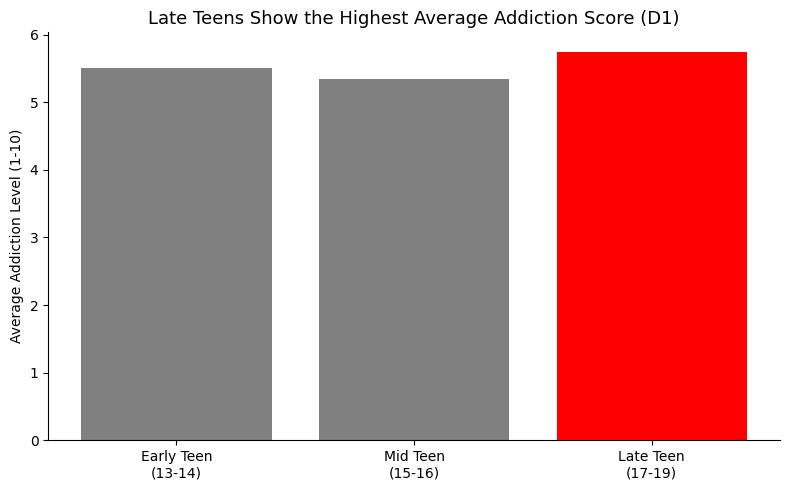

In [43]:
#Average addiction level by teen stage, D1
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN u.age <= 14 THEN 'Early Teen\n(13-14)'
                WHEN u.age <= 16 THEN 'Mid Teen\n(15-16)'
                ELSE 'Late Teen\n(17-19)'
            END AS teen_stage,
            ROUND(AVG(b.addiction_level), 2) AS avg_addiction
        FROM users_d1 u
        JOIN behavior_d1 b ON u.user_id = b.user_id
        GROUP BY teen_stage
        ORDER BY MIN(u.age);
    """)
    rows = cursor.fetchall()

stages = [row[0] for row in rows]
values = [row[1] for row in rows]
colors = ['gray' if v != max(values) else 'red' for v in values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(stages, values, color=colors)
ax.set_title('Late Teens Show the Highest Average Addiction Score (D1)', fontsize=13)
ax.set_ylabel('Average Addiction Level (1-10)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

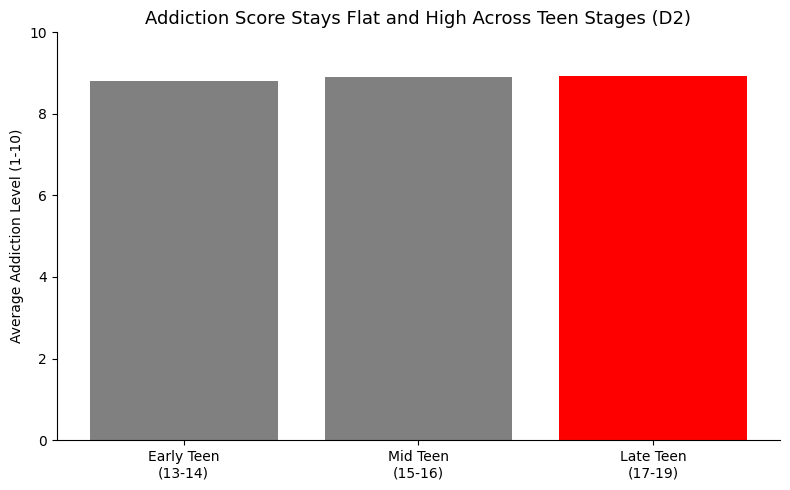

In [44]:
#Average addiction level by teen stage, D2
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()
    cursor.execute("""
        SELECT
            CASE
                WHEN u.age <= 14 THEN 'Early Teen\n(13-14)'
                WHEN u.age <= 16 THEN 'Mid Teen\n(15-16)'
                ELSE 'Late Teen\n(17-19)'
            END AS teen_stage,
            ROUND(AVG(b.addiction_level), 2) AS avg_addiction
        FROM users_d2 u
        JOIN behavior_d2 b ON u.user_id = b.user_id
        GROUP BY teen_stage
        ORDER BY MIN(u.age);
    """)
    rows = cursor.fetchall()

stages = [row[0] for row in rows]
values = [row[1] for row in rows]
colors = ['gray' if v != max(values) else 'red' for v in values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(stages, values, color=colors)
ax.set_title('Addiction Score Stays Flat and High Across Teen Stages (D2)', fontsize=13)
ax.set_ylabel('Average Addiction Level (1-10)')
ax.set_ylim(0, 10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

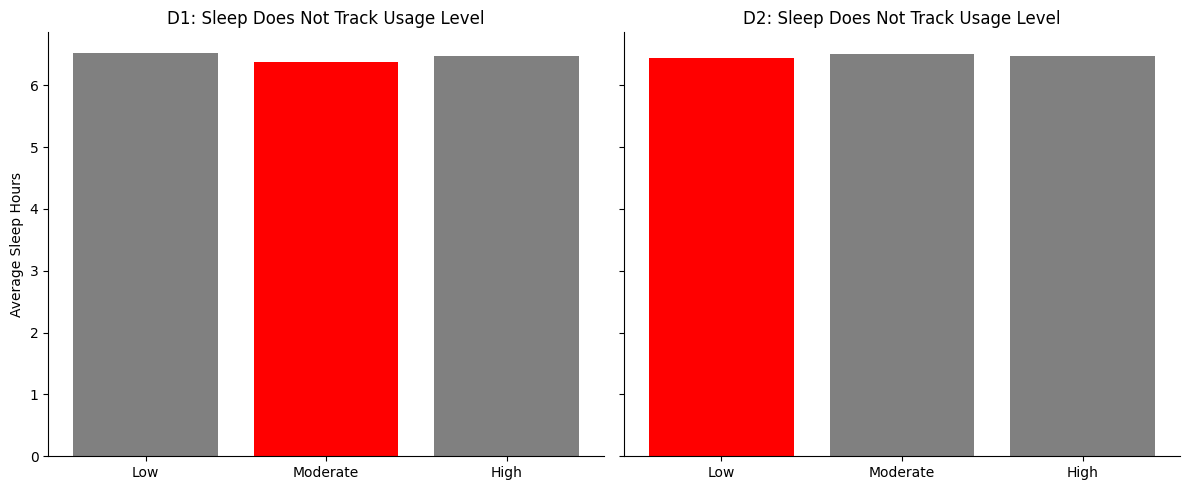

In [45]:
#Average sleep by usage bucket, D1 vs D2 side by side
with sqlite3.connect('Student_MentalHealth.db') as connection:
    cursor = connection.cursor()

    cursor.execute("""
        SELECT
            CASE
                WHEN daily_social_media_hours < 3 THEN 'Low'
                WHEN daily_social_media_hours < 6 THEN 'Moderate'
                ELSE 'High'
            END AS usage_bucket,
            ROUND(AVG(sleep_hours), 2)
        FROM hours_d1
        GROUP BY usage_bucket
        ORDER BY CASE usage_bucket WHEN 'Low' THEN 1 WHEN 'Moderate' THEN 2 ELSE 3 END;
    """)
    d1_rows = cursor.fetchall()

    cursor.execute("""
        SELECT
            CASE
                WHEN daily_usage_hours < 3 THEN 'Low'
                WHEN daily_usage_hours < 6 THEN 'Moderate'
                ELSE 'High'
            END AS usage_bucket,
            ROUND(AVG(sleep_hours), 2)
        FROM hours_d2
        GROUP BY usage_bucket
        ORDER BY CASE usage_bucket WHEN 'Low' THEN 1 WHEN 'Moderate' THEN 2 ELSE 3 END;
    """)
    d2_rows = cursor.fetchall()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

buckets1 = [r[0] for r in d1_rows]
vals1 = [r[1] for r in d1_rows]
colors1 = ['red' if v == min(vals1) else 'gray' for v in vals1]
axes[0].bar(buckets1, vals1, color=colors1)
axes[0].set_title('D1: Sleep Does Not Track Usage Level')
axes[0].set_ylabel('Average Sleep Hours')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

buckets2 = [r[0] for r in d2_rows]
vals2 = [r[1] for r in d2_rows]
colors2 = ['red' if v == min(vals2) else 'gray' for v in vals2]
axes[1].bar(buckets2, vals2, color=colors2)
axes[1].set_title('D2: Sleep Does Not Track Usage Level')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Both datasets independently fail to show a clean usage-to-sleep trend. The lowest-sleep bucket is different in each dataset, moderate in D1 and low in D2, and every gap sits under 15 minutes. This is a useful negative result: it argues against a simple story where more phone time directly costs sleep, at least not in a way this synthetic data captures.

Summary of findings-

1. Age alone does not separate usage or addiction levels in either dataset, both stay close to flat across early, mid, and late teens.
2. Usage level does not predict sleep in a clean way in either dataset, the lowest-sleep bucket differs between D1 and D2, and all gaps are small.
3. D2's addiction_level has a hard ceiling, just over half the dataset scores a perfect 10. Rerunning the age, gender, and phone usage purpose comparisons against phone_checks_per_day instead showed the ceiling was partly responsible for the flat results, age and phone usage purpose separate more once the cap is removed, though the gaps stay modest, under about 6 percent of the average in every case.
4. D1's depression_label group is tiny, 31 of 1200 rows, so its sleep gap is a real number but not a reliable conclusion.
5. Addiction bucket does not cleanly predict academic score or family communication in either dataset. D2's low addiction bucket only has 14 students, too small to trust, and the two buckets with real sample size land close together on both measures.
6. Both datasets are synthetic, so none of this establishes cause and effect. The value here is in the database design, the SQL query practice, and the comparison method, same conclusion the Smartphone project reached with its own two datasets.